# Project: end-to-end Jena climate forecasting

**Learning objective:** Take real multivariate weather observations from acquisition through validation, recurrent-model comparison, final test evaluation, saved-model inference and drift checks.

This notebook is part of the TensorFlow/Keras learning track. It is designed to be read top-to-bottom: intuition → shapes → mathematics → TensorFlow implementation → observed result → interpretation.

> GitHub renders the committed executed output as a static learning artifact. Clone the repository and rerun it in Jupyter/VS Code for live experimentation.


In [1]:
import os, warnings, random
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__ if hasattr(tf.keras, "__version__") else "bundled with TensorFlow")
print("Execution device(s):", [d.device_type for d in tf.config.list_logical_devices()])

from sklearn.metrics import mean_absolute_error, mean_squared_error
import json, zipfile, time
PROJECT=Path("RNN/projects/jena_climate_forecasting")
(PROJECT/"artifacts").mkdir(parents=True,exist_ok=True)
(PROJECT/"reports").mkdir(parents=True,exist_ok=True)


2026-09-21 07:14:06.946764: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789974846.962105    3290 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789974846.966474    3290 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.1
Keras: 3.15.1
Execution device(s): ['CPU']


2026-09-21 07:14:08.615777: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 1. Problem and data contract
        **Goal:** predict temperature one hour ahead using the previous 24 hourly observations of temperature, pressure and air density.

        We use real Jena weather-station observations. The original 10-minute stream is downsampled to hourly resolution. Splits are chronological and normalization statistics come from training data only.


In [2]:
url="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path=tf.keras.utils.get_file("jena_climate_2009_2016.csv.zip",origin=url,extract=False)
with zipfile.ZipFile(zip_path) as zf:
    with zf.open("jena_climate_2009_2016.csv") as f: raw=pd.read_csv(f)
print("raw shape:",raw.shape); display(raw.head(3)); print("missing cells:",int(raw.isna().sum().sum()))


       0/13568290 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

  598016/13568290 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

 4202496/13568290 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


raw shape: (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6


missing cells: 0


## 2. EDA and hourly sampling
        The timestamp column is parsed, observations are sampled every sixth row (10-minute → hourly), and a compact 8,000-hour teaching slice keeps execution CPU-friendly while preserving real temporal structure.


,count,mean,std,min,25%,50%,75%,max
T (degC),8000.0,9.702,8.186,-23.01,4.100,10.13,15.662,32.98
p (mbar),8000.0,988.576,8.407,944.64,984.080,989.60,994.450,1005.52
rho (g/m**3),8000.0,1214.052,38.611,1120.99,1187.535,1210.22,1234.650,1383.38


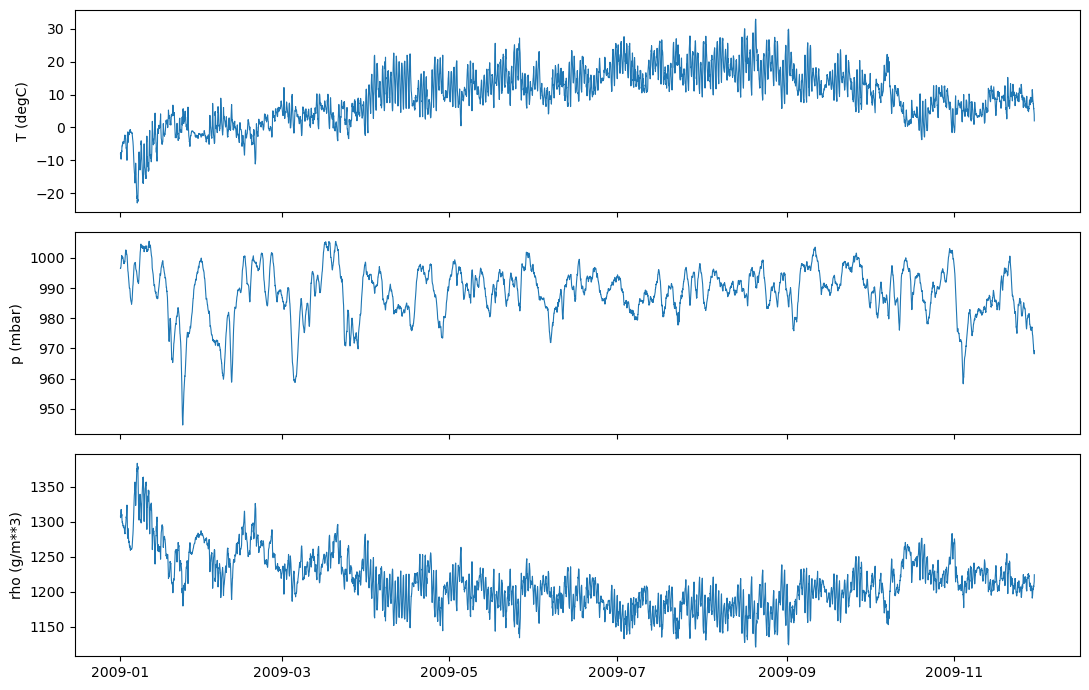

In [3]:
df=raw.iloc[::6].copy().iloc[:8000]
df["Date Time"]=pd.to_datetime(df["Date Time"],format="%d.%m.%Y %H:%M:%S")
features=["T (degC)","p (mbar)","rho (g/m**3)"]
display(df[features].describe().T.round(3))
fig,axes=plt.subplots(3,1,figsize=(11,7),sharex=True)
for col,ax in zip(features,axes): ax.plot(df["Date Time"],df[col],lw=.8); ax.set_ylabel(col)
plt.tight_layout(); plt.show()


## 3. Chronological split and leakage-safe normalization
        70% train, 15% validation, 15% test. Mean/std are fitted on the training partition and then reused unchanged.


In [4]:
values=df[features].to_numpy(dtype="float32")
n=len(values); train_end=int(n*.70); val_end=int(n*.85)
mean=values[:train_end].mean(axis=0); std=values[:train_end].std(axis=0)
norm=(values-mean)/std
print("boundaries:",train_end,val_end,n); print("train mean after scaling:",np.round(norm[:train_end].mean(axis=0),4))


boundaries: 5600 6800 8000
train mean after scaling: [ 0. -0. -0.]


## 4. Windowing
        A sample is 24 consecutive hourly vectors; the label is next-hour normalized temperature. Windows are assigned to a split according to the target timestamp, so no test target appears in training.


In [5]:
lookback=24; target_col=0
X=[]; y=[]; target_idx=[]
for i in range(lookback,len(norm)):
    X.append(norm[i-lookback:i]); y.append(norm[i,target_col]); target_idx.append(i)
X=np.asarray(X,dtype="float32"); y=np.asarray(y,dtype="float32"); target_idx=np.asarray(target_idx)
tr=target_idx<train_end; va=(target_idx>=train_end)&(target_idx<val_end); te=target_idx>=val_end
Xtr,ytr=X[tr],y[tr]; Xva,yva=X[va],y[va]; Xte,yte=X[te],y[te]
print("train/val/test:",Xtr.shape,Xva.shape,Xte.shape)


train/val/test: (5576, 24, 3) (1200, 24, 3) (1200, 24, 3)


## 5. Baseline first
        The last observed temperature is a strong one-hour baseline. Neural models need to improve on it to justify their complexity.


In [6]:
def inv_temp(z): return z*std[0]+mean[0]
yte_real=inv_temp(yte); naive_real=inv_temp(Xte[:,-1,0])
baseline={"MAE":mean_absolute_error(yte_real,naive_real),"RMSE":mean_squared_error(yte_real,naive_real)**0.5}
display(pd.DataFrame([{"model":"last value",**baseline}]).round(4))


,model,MAE,RMSE
0,last value,0.5293,0.7634


## 6. Train SimpleRNN, LSTM and GRU under the same contract
        Architecture width, optimizer, epochs and input windows are intentionally aligned so the comparison isolates the recurrent cell choice.


In [7]:
def build(kind):
    cls={"SimpleRNN":tf.keras.layers.SimpleRNN,"LSTM":tf.keras.layers.LSTM,"GRU":tf.keras.layers.GRU}[kind]
    m=tf.keras.Sequential([tf.keras.layers.Input((lookback,len(features))),cls(16),tf.keras.layers.Dense(1)],name=kind.lower())
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3,clipnorm=1.0),loss="mse",metrics=["mae"]); return m
histories={}; models={}; rows=[]
for kind in ["SimpleRNN","LSTM","GRU"]:
    tf.keras.backend.clear_session(); tf.keras.utils.set_random_seed(SEED)
    m=build(kind)
    h=m.fit(Xtr,ytr,validation_data=(Xva,yva),epochs=2,batch_size=64,verbose=0)
    histories[kind]=h.history; models[kind]=m
    rows.append({"model":kind,"best_val_mae_norm":min(h.history["val_mae"]),"parameters":m.count_params()})
comparison=pd.DataFrame(rows).sort_values("best_val_mae_norm"); display(comparison.round(4))


,model,best_val_mae_norm,parameters
0,SimpleRNN,0.0845,337
2,GRU,0.1242,1025
1,LSTM,0.2319,1297


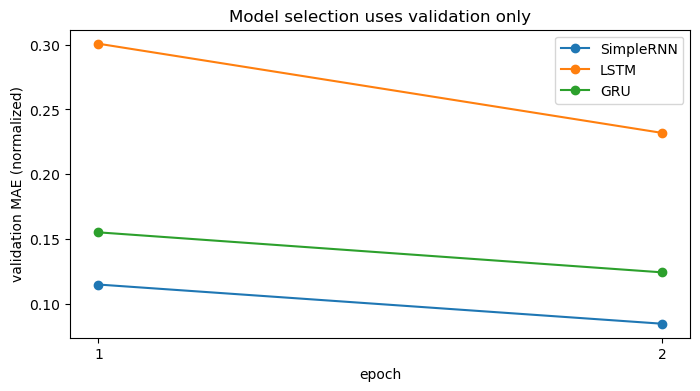

In [8]:
plt.figure(figsize=(8,4))
for kind,h in histories.items(): plt.plot(h["val_mae"],marker="o",label=kind)
plt.xlabel("epoch"); plt.ylabel("validation MAE (normalized)"); plt.xticks(range(2),[1,2]); plt.legend(); plt.title("Model selection uses validation only"); plt.show()


## 7. Final untouched test evaluation
        We choose the model with the lowest validation MAE, then evaluate that model on test exactly once for the final headline result.


In [9]:
best=comparison.iloc[0]["model"]; best_model=models[best]
pred_norm=best_model.predict(Xte,batch_size=128,verbose=0).ravel(); pred=inv_temp(pred_norm)
test_mae=mean_absolute_error(yte_real,pred); test_rmse=mean_squared_error(yte_real,pred)**0.5
metrics={"selected_model":best,"baseline_mae":float(baseline["MAE"]),"baseline_rmse":float(baseline["RMSE"]),"test_mae":float(test_mae),"test_rmse":float(test_rmse)}
display(pd.DataFrame([metrics]).round(4))


,selected_model,baseline_mae,baseline_rmse,test_mae,test_rmse
0,SimpleRNN,0.5293,0.7634,0.696,0.9249


## 8. Error analysis
        Aggregate errors can hide temporal regimes, so we inspect a forecast segment and residual distribution.


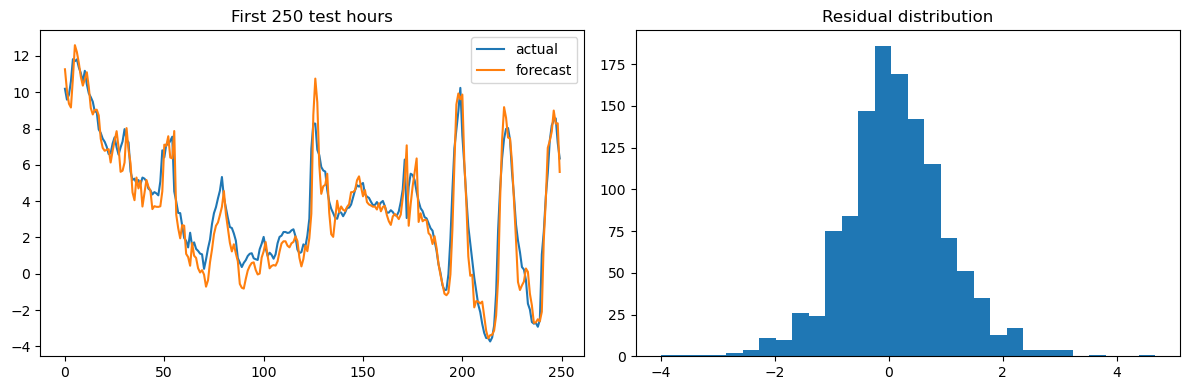

largest absolute errors (°C): [3.32 3.55 3.58 4.01 4.67]


In [10]:
resid=yte_real-pred
fig,axes=plt.subplots(1,2,figsize=(12,4)); axes[0].plot(yte_real[:250],label="actual"); axes[0].plot(pred[:250],label="forecast"); axes[0].legend(); axes[0].set_title("First 250 test hours"); axes[1].hist(resid,bins=30); axes[1].set_title("Residual distribution"); plt.tight_layout(); plt.show()
print("largest absolute errors (°C):",np.round(np.sort(np.abs(resid))[-5:],2))


## 9. Persist model, preprocessing contract and predictions


In [11]:
model_path=PROJECT/"artifacts"/"best_model.keras"; best_model.save(model_path)
(PROJECT/"artifacts"/"preprocessing.json").write_text(json.dumps({"features":features,"mean":mean.tolist(),"std":std.tolist(),"lookback":lookback},indent=2))
(PROJECT/"reports"/"metrics.json").write_text(json.dumps(metrics,indent=2))
pd.DataFrame({"actual_temp_c":yte_real[:500],"predicted_temp_c":pred[:500],"residual_c":resid[:500]}).to_csv(PROJECT/"reports"/"predictions.csv",index=False)
pd.DataFrame({k:v for k,v in histories[best].items()}).to_csv(PROJECT/"reports"/"training_history.csv",index=False)
print("saved:",model_path); print("artifact files:",[p.name for p in sorted((PROJECT/"artifacts").iterdir())])


saved: RNN/projects/jena_climate_forecasting/artifacts/best_model.keras
artifact files: ['best_model.keras', 'preprocessing.json']


## 10. Reloaded inference and monitoring signal
        Reloading is part of the test: an artifact is useful only if it can independently reproduce inference. We also compare train/test feature means in standardized units as a simple drift diagnostic.


In [12]:
reloaded=tf.keras.models.load_model(model_path)
one=float(inv_temp(reloaded.predict(Xte[:1],verbose=0).ravel())[0])
print("one reloaded prediction °C:",round(one,3),"actual:",round(float(yte_real[0]),3))
drift=pd.DataFrame({"feature":features,"train_mean":values[:train_end].mean(0),"test_mean":values[val_end:].mean(0),"shift_in_train_std":(values[val_end:].mean(0)-values[:train_end].mean(0))/std})
display(drift.round(3))


one reloaded prediction °C: 11.265 actual: 10.19


,feature,train_mean,test_mean,shift_in_train_std
0,T (degC),9.369000,6.441000,-0.325
1,p (mbar),988.434021,986.257019,-0.250
2,rho (g/m**3),1215.639038,1225.212036,0.223


## Production interpretation
        The notebook demonstrates the complete experiment lifecycle. A production system would additionally version raw data snapshots, schedule label-aware performance monitoring, alert on data-quality/drift thresholds, and retrain only through a validated promotion process.
